In [27]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from mpl_toolkits.mplot3d import Axes3D
from scipy.signal import argrelextrema

# Part A - Discrete Chaotic Systems

## A.2 Logistic Map

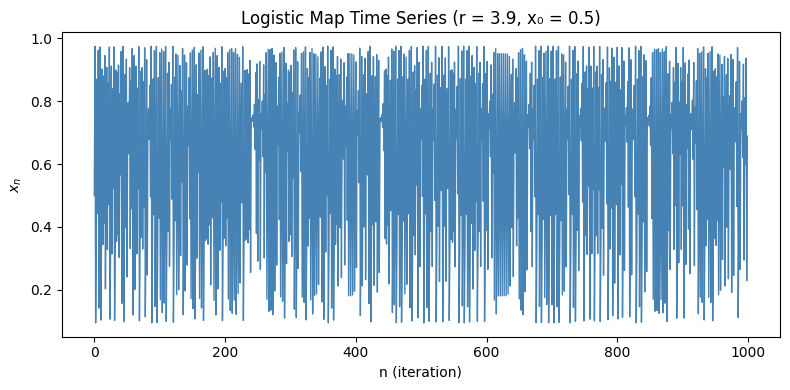

In [10]:
r = 3.9
x0 = 0.5
n_iter = 1000

x = np.zeros(n_iter)
x[0] = x0
for n in range(1, n_iter):
    x[n] = r * x[n-1] * (1 - x[n-1])

plt.figure(figsize=(8, 4))
plt.plot(x, lw=1, color='steelblue')
plt.xlabel('n (iteration)')
plt.ylabel(r'$x_n$')
plt.title(f'Logistic Map Time Series (r = {r}, x₀ = {x0})')
plt.tight_layout()
plt.show()

## A.3 Hénon Map

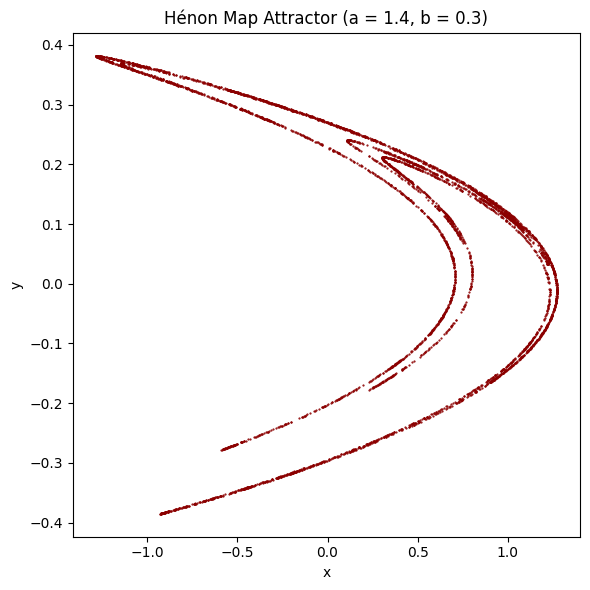

In [3]:
a, b = 1.4, 0.3
x0, y0 = 0.0, 0.0
n_iter = 5000
n_transient = 200

xs, ys = np.zeros(n_iter), np.zeros(n_iter)
xs[0], ys[0] = x0, y0
for n in range(1, n_iter):
    xs[n] = 1 - a * xs[n-1]**2 + ys[n-1]
    ys[n] = b * xs[n-1]

plt.figure(figsize=(6, 6))
plt.scatter(xs[n_transient:], ys[n_transient:], s=0.3, color='darkred')
plt.xlabel('x')
plt.ylabel('y')
plt.title(f'Hénon Map Attractor (a = {a}, b = {b})')
plt.tight_layout()
plt.show()

## A.4 Bifurcation Diagrams

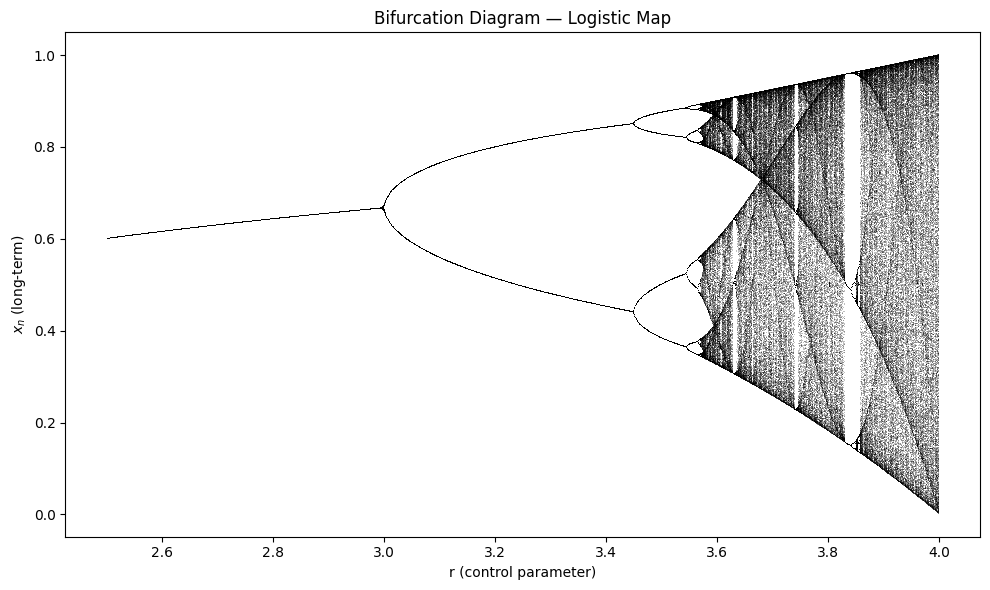

In [6]:
r_values = np.arange(2.5, 4.0, 0.001)
n_iter = 1000
n_transient = 500

x = np.full_like(r_values, 0.5)

plt.figure(figsize=(10, 6))
for i in range(n_iter):
    x = r_values * x * (1 - x)
    if i >= n_transient:
        plt.plot(r_values, x, ',k', alpha=0.25)

plt.xlabel('r (control parameter)')
plt.ylabel(r'$x_n$ (long-term)')
plt.title('Bifurcation Diagram — Logistic Map')
plt.tight_layout()
plt.show()

System starts as a stable system then before r reachiing 3.6 it turned into a chaotic system showing how control parameter can control the system from a stable (this is the case here )or periodic into a chotic system

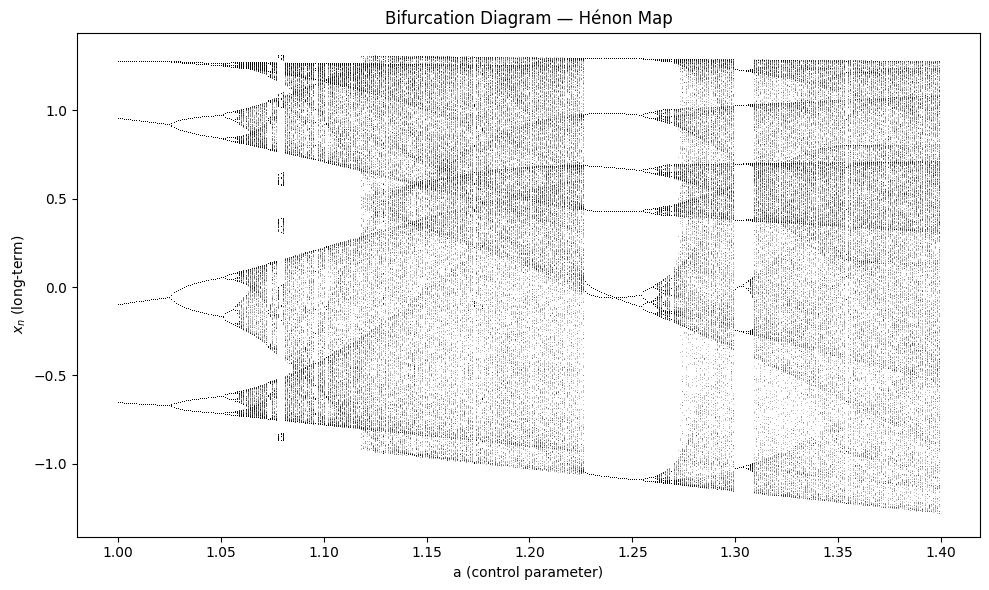

In [8]:
a_values = np.arange(1.0, 1.4, 0.001)
b_fixed = 0.3
n_iter = 1000
n_transient = 500

x = np.zeros_like(a_values)
y = np.zeros_like(a_values)

plt.figure(figsize=(10, 6))
for i in range(n_iter):
    x_new = 1 - a_values * x**2 + y
    y_new = b_fixed * x
    x, y = x_new, y_new
    if i >= n_transient:
        plt.plot(a_values, x, ',k', alpha=0.25)

plt.xlabel('a (control parameter)')
plt.ylabel(r'$x_n$ (long-term)')
plt.title('Bifurcation Diagram — Hénon Map')
plt.tight_layout()
plt.savefig('henon_bifurcation.png')
plt.show()

low a values give a single stable branch, which period-doubles as a increases, then breaks into the chaos. Thin periodic windows are again visible inside the chaotic region, confirming that the route to chaos in the Hénon map.

# Part B — Continuous Chaotic Systems

## B.2 Lorenz System

In [15]:
def lorenz(t, state, sigma=10, rho=28, beta=8/3):
    x, y, z = state
    dx = sigma * (y - x)
    dy = x * (rho - z) - y
    dz = x * y - beta * z
    return [dx, dy, dz]

ic = [1, 1, 1]
dt = 0.01
T = 50
t_eval = np.arange(0, T, dt)

sol_lorenz = solve_ivp(lorenz, [0, T], ic, method='RK45',
                        t_eval=t_eval, args=(10, 28, 8/3))
x, y, z = sol_lorenz.y

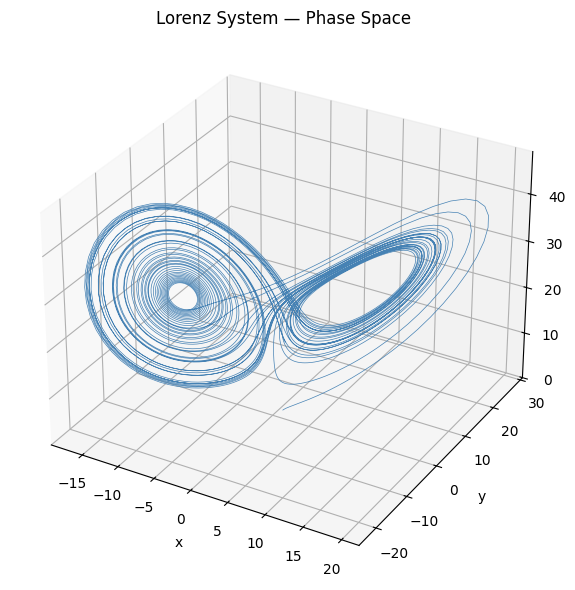

In [16]:
# 3-D phase-space plot
fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection='3d')
ax.plot(x, y, z, lw=0.5, color='steelblue')
ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('z')
ax.set_title('Lorenz System — Phase Space')
plt.tight_layout()
plt.savefig('lorenz_phase.png')
plt.show()

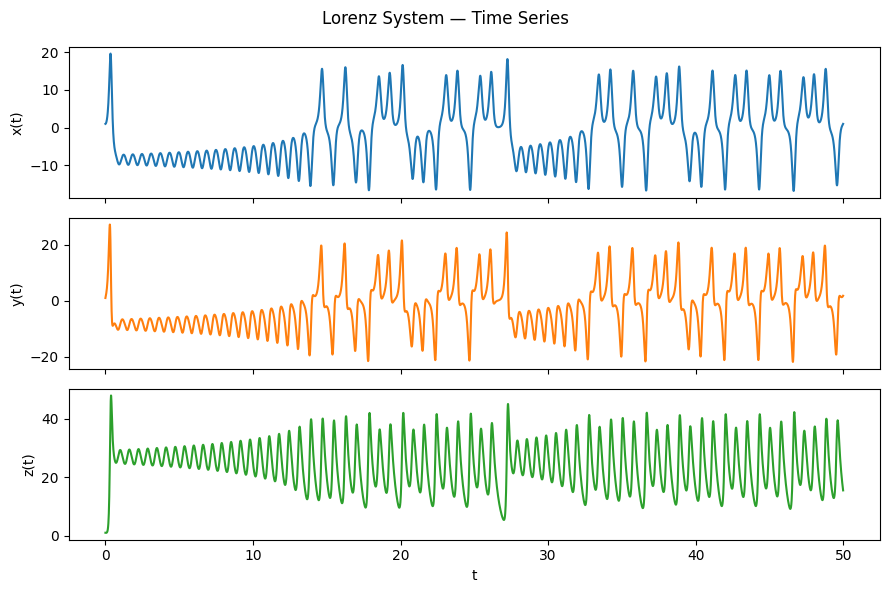

In [17]:
# Time series
fig, axs = plt.subplots(3, 1, figsize=(9, 6), sharex=True)
axs[0].plot(sol_lorenz.t, x, color='tab:blue');  axs[0].set_ylabel('x(t)')
axs[1].plot(sol_lorenz.t, y, color='tab:orange'); axs[1].set_ylabel('y(t)')
axs[2].plot(sol_lorenz.t, z, color='tab:green'); axs[2].set_ylabel('z(t)')
axs[2].set_xlabel('t')
fig.suptitle('Lorenz System — Time Series')
plt.tight_layout()
plt.savefig('lorenz_timeseries.png')
plt.show()

Equations: <br>ẋ = σ(y−x)<br> ẏ = x(ρ−z)−y<br> ż = xy−βz <br>
Settings: σ=10, ρ=28, β=8/3, IC=(1,1,1), dt=0.01, T=50, solver=RK45 <br>


## B.3 Rössler System

In [18]:
def rossler(t, state, a=0.2, b=0.2, c=5.7):
    x, y, z = state
    dx = -y - z
    dy = x + a * y
    dz = b + z * (x - c)
    return [dx, dy, dz]

ic = [1, 1, 1]
dt = 0.01
T = 250
t_eval = np.arange(0, T, dt)

sol_rossler = solve_ivp(rossler, [0, T], ic, method='RK45',
                         t_eval=t_eval, args=(0.2, 0.2, 5.7))

x, y, z = sol_rossler.y

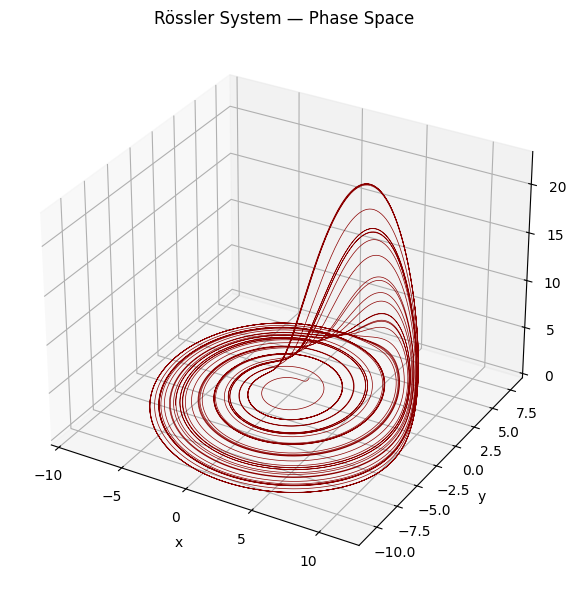

In [19]:
fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection='3d')
ax.plot(x, y, z, lw=0.5, color='darkred')
ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('z')
ax.set_title('Rössler System — Phase Space')
plt.tight_layout()
plt.savefig('rossler_phase.png')
plt.show()

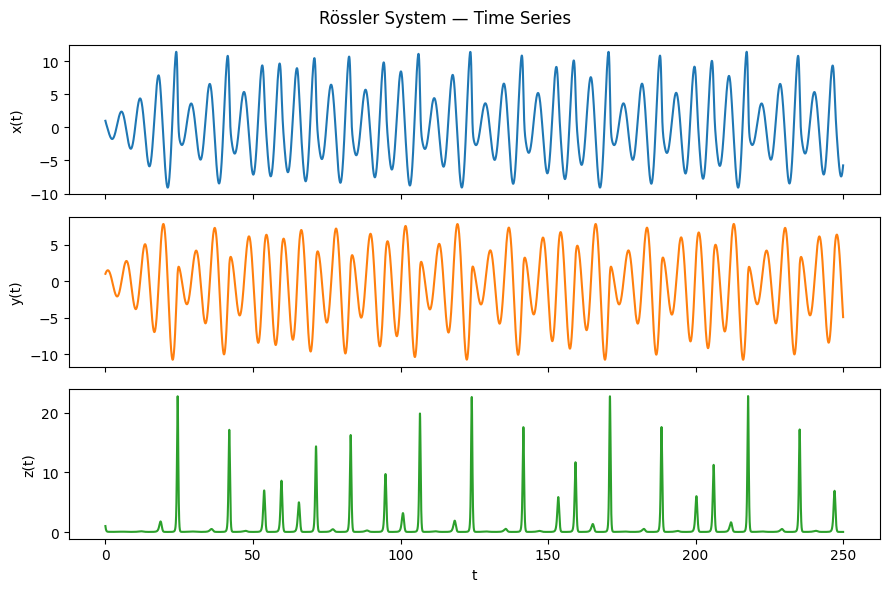

In [20]:
fig, axs = plt.subplots(3, 1, figsize=(9, 6), sharex=True)
axs[0].plot(sol_rossler.t, x, color='tab:blue');  axs[0].set_ylabel('x(t)')
axs[1].plot(sol_rossler.t, y, color='tab:orange'); axs[1].set_ylabel('y(t)')
axs[2].plot(sol_rossler.t, z, color='tab:green'); axs[2].set_ylabel('z(t)')
axs[2].set_xlabel('t')
fig.suptitle('Rössler System — Time Series')
plt.tight_layout()
plt.savefig('rossler_timeseries.png')
plt.show()

Equations:<br> ẋ = −y−z <br>ẏ = x+a·y <br> ż = b+z(x−c) <br>
Settings: a=0.2, b=0.2, c=5.7, IC=(1,1,1), dt=0.01, T=250, solver=RK45

## B.4 Chen System

In [21]:
def chen(t, state, a=35, b=3, c=28):
    x, y, z = state
    dx = a * (y - x)
    dy = (c - a) * x - x * z + c * y
    dz = x * y - b * z
    return [dx, dy, dz]

ic = [-0.1, 0.5, -0.6]
dt = 0.002
T = 50
t_eval = np.arange(0, T, dt)

sol_chen = solve_ivp(chen, [0, T], ic, method='RK45',
                      t_eval=t_eval, args=(35, 3, 28), max_step=dt)

x, y, z = sol_chen.y

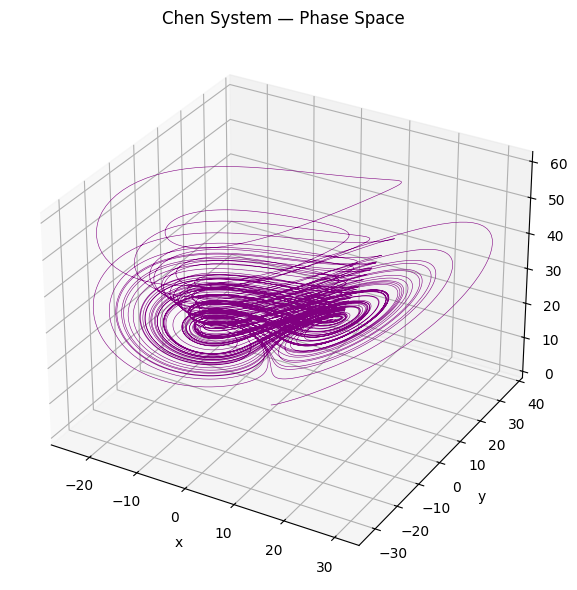

In [22]:
fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection='3d')
ax.plot(x, y, z, lw=0.4, color='purple')
ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('z')
ax.set_title('Chen System — Phase Space')
plt.tight_layout()
plt.savefig('chen_phase.png')
plt.show()

unlike Lorenz's single-lobe butterfly, Chen produces a double-scroll attractor with two distinct wings.

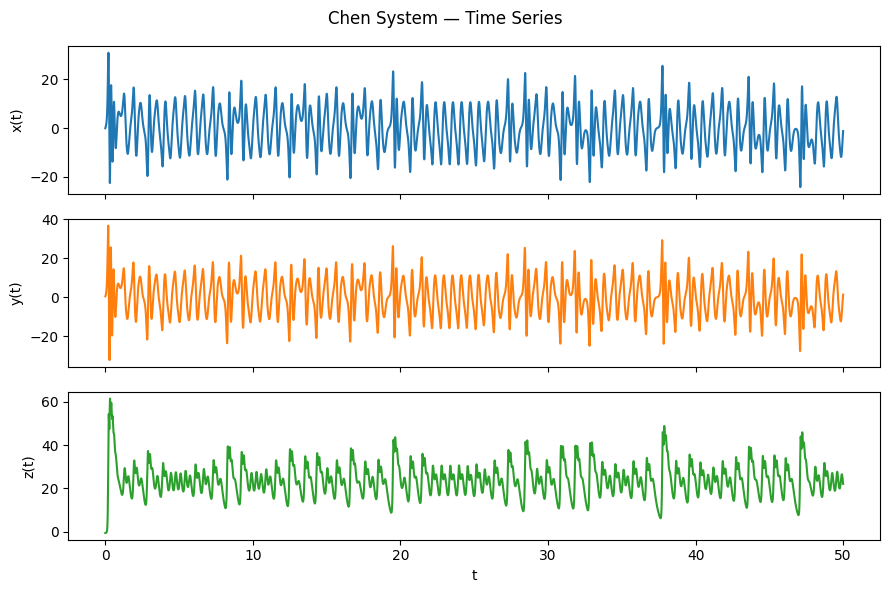

In [23]:
fig, axs = plt.subplots(3, 1, figsize=(9, 6), sharex=True)
axs[0].plot(sol_chen.t, x, color='tab:blue');  axs[0].set_ylabel('x(t)')
axs[1].plot(sol_chen.t, y, color='tab:orange'); axs[1].set_ylabel('y(t)')
axs[2].plot(sol_chen.t, z, color='tab:green'); axs[2].set_ylabel('z(t)')
axs[2].set_xlabel('t')
fig.suptitle('Chen System — Time Series')
plt.tight_layout()
plt.savefig('chen_timeseries.png')
plt.show()


Equations:<br> ẋ = a(y−x)<br> ẏ = (c−a)x−xz+cy <br> ż = xy−bz<br>
Settings: a=35, b=3, c=28, IC=(−0.1, 0.5, −0.6), dt=0.002, T=50, solver=RK45

##  B.5 Hyperchaotic Rössler System (4D)

In [24]:
def hyper_rossler(t, state, a=0.25, b=3, c=0.5, d=0.05):
    x, y, z, w = state
    dx = -y - z
    dy = x + a * y + w
    dz = b + x * z
    dw = -c * z + d * w
    return [dx, dy, dz, dw]

ic = [-10, -6, 0, 10]
dt = 0.01
T = 250
t_eval = np.arange(0, T, dt)

sol_hyper = solve_ivp(hyper_rossler, [0, T], ic, method='RK45',
                       t_eval=t_eval, args=(0.25, 3, 0.5, 0.05))

x, y, z, w = sol_hyper.y

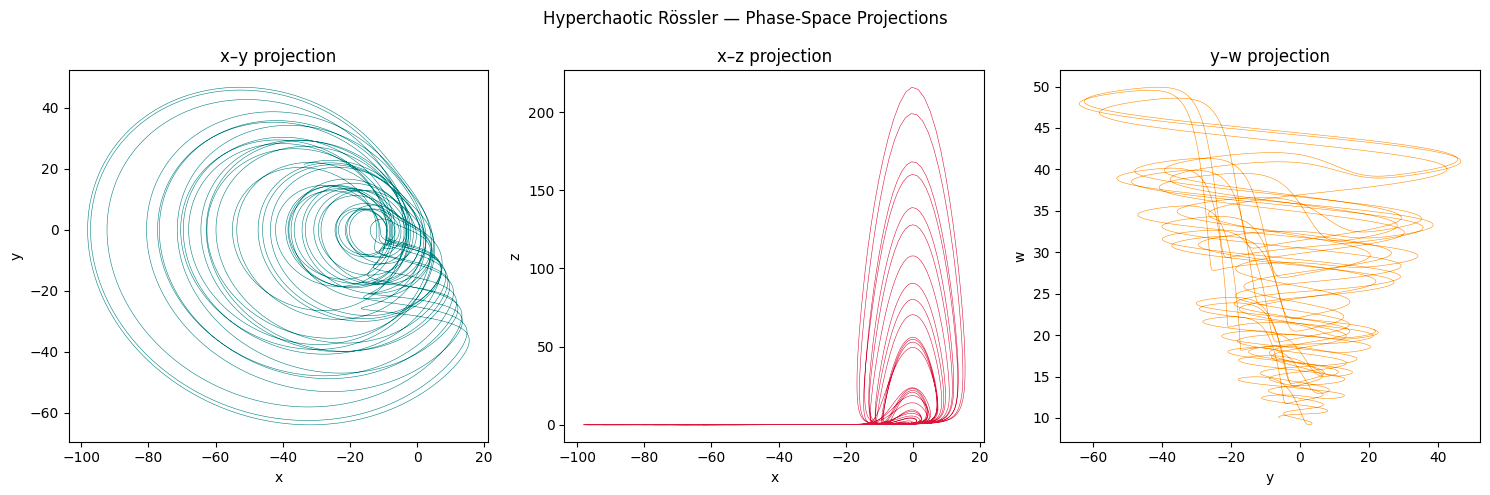

In [25]:
# 2D projections (full 4D can't be drawn directly)
fig, axs = plt.subplots(1, 3, figsize=(15, 5))
axs[0].plot(x, y, lw=0.4, color='teal');    axs[0].set_xlabel('x'); axs[0].set_ylabel('y'); axs[0].set_title('x–y projection')
axs[1].plot(x, z, lw=0.4, color='crimson'); axs[1].set_xlabel('x'); axs[1].set_ylabel('z'); axs[1].set_title('x–z projection')
axs[2].plot(y, w, lw=0.4, color='darkorange'); axs[2].set_xlabel('y'); axs[2].set_ylabel('w'); axs[2].set_title('y–w projection')
fig.suptitle('Hyperchaotic Rössler — Phase-Space Projections')
plt.tight_layout()
plt.savefig('hyperrossler_phase.png')
plt.show()

since this is 4D, no single plot shows the full attractor — the projections and the second positive Lyapunov exponent (visible as the extra "wandering" in w(t)) are what distinguish it from ordinary chaos.

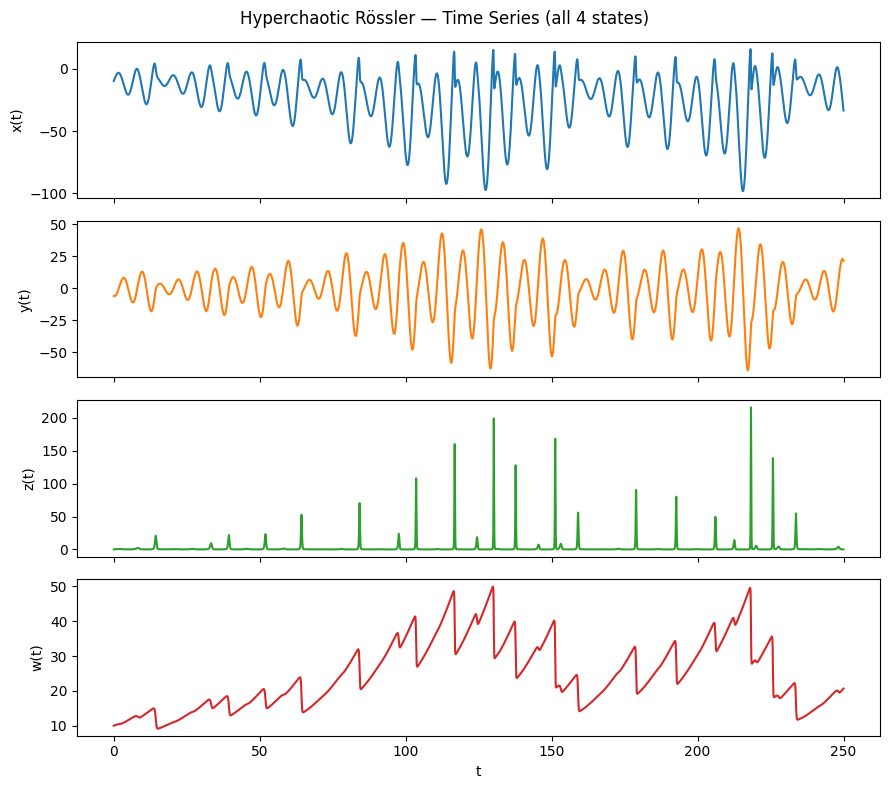

In [26]:
# Time series of all four states
fig, axs = plt.subplots(4, 1, figsize=(9, 8), sharex=True)
axs[0].plot(sol_hyper.t, x, color='tab:blue');   axs[0].set_ylabel('x(t)')
axs[1].plot(sol_hyper.t, y, color='tab:orange'); axs[1].set_ylabel('y(t)')
axs[2].plot(sol_hyper.t, z, color='tab:green');  axs[2].set_ylabel('z(t)')
axs[3].plot(sol_hyper.t, w, color='tab:red');    axs[3].set_ylabel('w(t)')
axs[3].set_xlabel('t')
fig.suptitle('Hyperchaotic Rössler — Time Series (all 4 states)')
plt.tight_layout()
plt.savefig('hyperrossler_timeseries.png')
plt.show()

Equations: <br> ẋ = −y−z, <br>  ẏ = x+a·y+w, <br> ż = b+xz, <br> ẇ = −c·z+d·w
<br> Settings: a=0.25, b=3, c=0.5, d=0.05, IC=(−10, −6, 0, 10), dt=0.01, T=250, solver=RK45


## Part C — Sensitivity Analysis

## C.1 ρ-Sweep of the Lorenz System

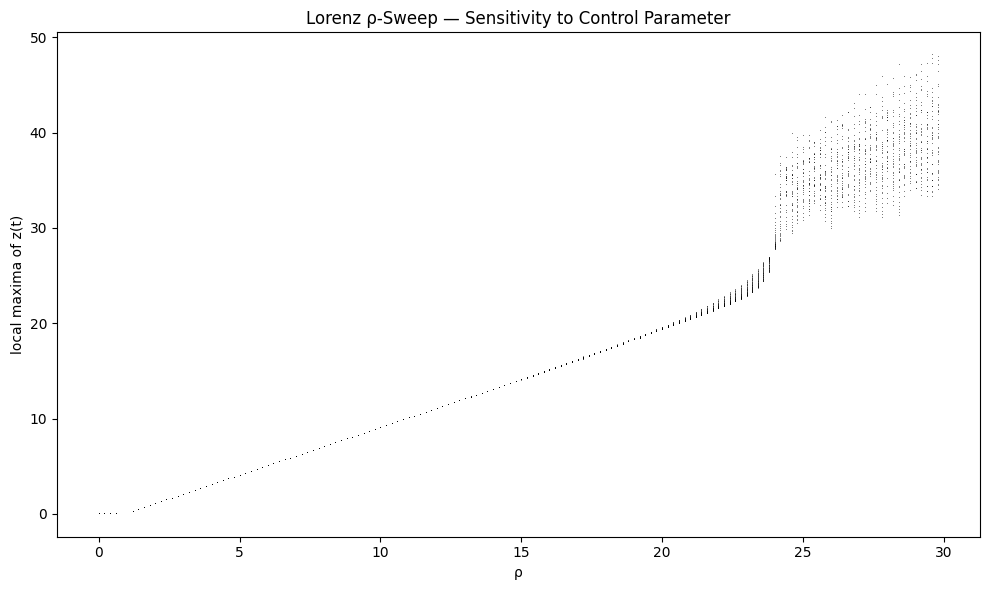

In [30]:

sigma, beta = 10, 8/3
ic = [1, 1, 1]
dt = 0.01
T = 50
t_eval = np.arange(0, T, dt)
transient_time = 20

rho_values = np.arange(0, 30, 0.2)
rho_plot, zmax_plot = [], []

for rho in rho_values:
    sol = solve_ivp(lorenz, [0, T], ic, method='RK45',
                     t_eval=t_eval, args=(sigma, rho, beta))
    t, z = sol.t, sol.y[2]
    z_post = z[t >= transient_time]
    idx = argrelextrema(z_post, np.greater)[0]
    zmax_plot.extend(z_post[idx])
    rho_plot.extend([rho] * len(idx))

plt.figure(figsize=(10, 6))
plt.plot(rho_plot, zmax_plot, ',k', alpha=0.5)
plt.xlabel('ρ')
plt.ylabel('local maxima of z(t)')
plt.title('Lorenz ρ-Sweep — Sensitivity to Control Parameter')
plt.tight_layout()
plt.savefig('lorenz_rho_sweep.png')
plt.show()

### Discussion

For ρ below about 25 the trajectory is stable, so the recorded maxima stay confined to a few narrow values (or none, before the first bifurcation). Past ρ ≈ 25 the fixed points lose stability and the local maxima fan out into a broad, continuous band — the signature of chaos — with occasional narrow periodic windows visible inside that band. This mirrors the period-doubling-to-chaos route seen in the discrete bifurcation diagrams of Part A, showing that continuous flows and discrete maps share the same underlying route to chaos even though one evolves in continuous time and the other in iteration steps.

##  C.2 Step-Size Sensitivity

In [31]:
def rk4_integrate(f, ic, dt, T, args=()):
    n_steps = int(round(T / dt))
    t = np.linspace(0, n_steps * dt, n_steps + 1)
    state = np.zeros((n_steps + 1, len(ic)))
    state[0] = ic
    for i in range(n_steps):
        s = state[i]
        k1 = np.array(f(t[i], s, *args))
        k2 = np.array(f(t[i] + dt/2, s + dt/2*k1, *args))
        k3 = np.array(f(t[i] + dt/2, s + dt/2*k2, *args))
        k4 = np.array(f(t[i] + dt,   s + dt*k3,   *args))
        state[i+1] = s + (dt/6) * (k1 + 2*k2 + 2*k3 + k4)
    return t, state

ic = [1, 1, 1]
T = 50
sigma, rho, beta = 10, 28, 8/3

dts = {'fine (dt=0.001)': 0.001, 'baseline (dt=0.01)': 0.01, 'coarse (dt=0.05)': 0.05}
colors = {'fine (dt=0.001)': 'tab:blue', 'baseline (dt=0.01)': 'tab:orange', 'coarse (dt=0.05)': 'tab:green'}

results = {}
for label, dt in dts.items():
    t, state = rk4_integrate(lorenz, ic, dt, T, args=(sigma, rho, beta))
    results[label] = (t, state)

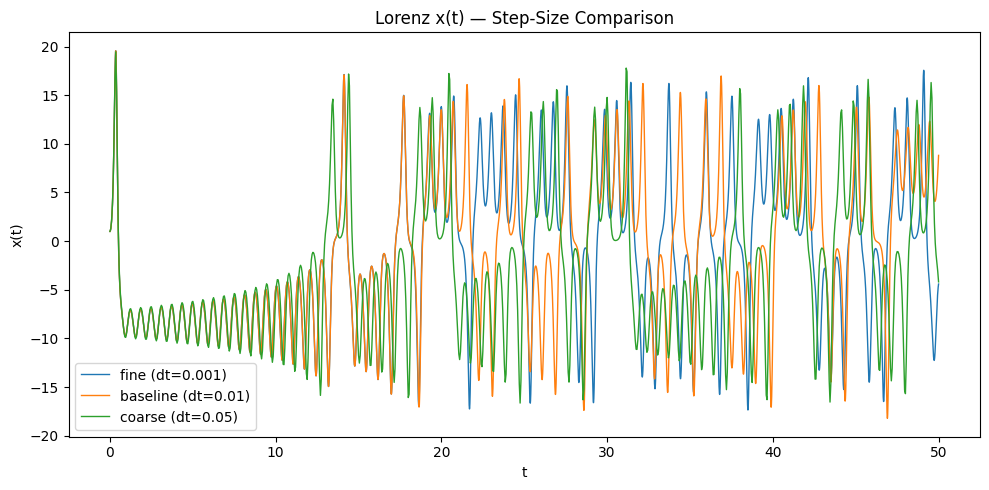

In [32]:
# (i) overlay x(t)
plt.figure(figsize=(10, 5))
for label, (t, state) in results.items():
    plt.plot(t, state[:, 0], label=label, color=colors[label], lw=1)
plt.xlabel('t'); plt.ylabel('x(t)')
plt.title('Lorenz x(t) — Step-Size Comparison')
plt.legend()
plt.tight_layout()
plt.savefig('stepsize_x_overlay.png')
plt.show()

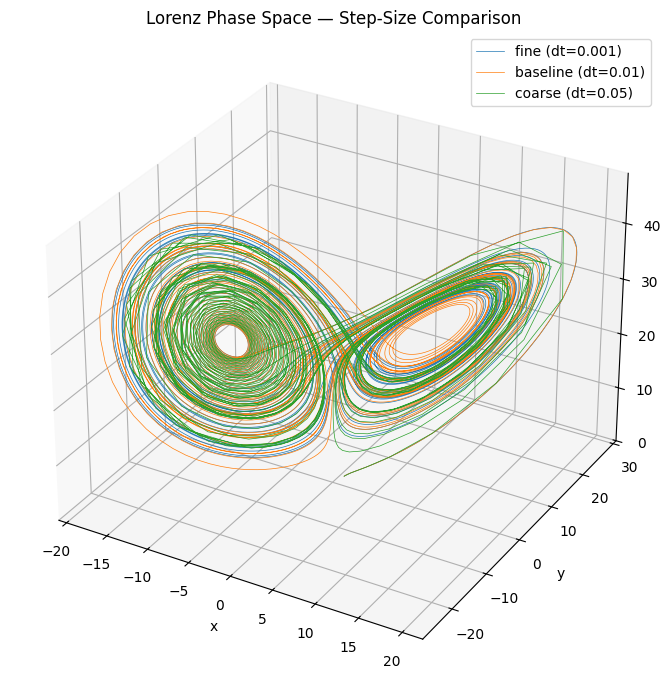

In [33]:
# (ii) overlay 3-D phase-space trajectories
fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(111, projection='3d')
for label, (t, state) in results.items():
    ax.plot(state[:, 0], state[:, 1], state[:, 2], lw=0.5,
             label=label, color=colors[label])
ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('z')
ax.set_title('Lorenz Phase Space — Step-Size Comparison')
ax.legend()
plt.tight_layout()
plt.savefig('stepsize_phase_overlay.png')
plt.show()

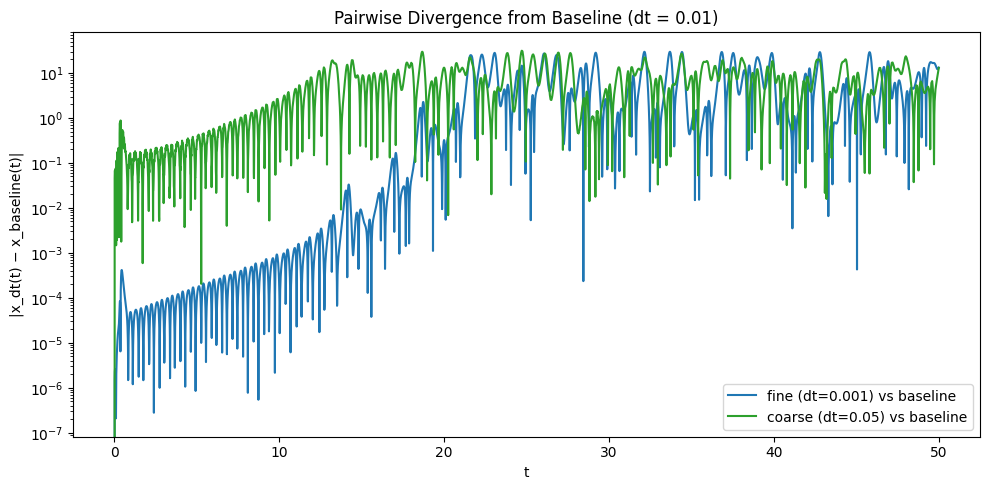

In [34]:
# (iii) pairwise divergence from baseline
t_base, state_base = results['baseline (dt=0.01)']
x_base = state_base[:, 0]

plt.figure(figsize=(10, 5))
for label in ['fine (dt=0.001)', 'coarse (dt=0.05)']:
    t, state = results[label]
    x_interp = np.interp(t_base, t, state[:, 0])
    divergence = np.abs(x_interp - x_base)
    plt.plot(t_base, divergence, label=f'{label} vs baseline', color=colors[label])
plt.xlabel('t'); plt.ylabel('|x_dt(t) − x_baseline(t)|')
plt.yscale('log')
plt.title('Pairwise Divergence from Baseline (dt = 0.01)')
plt.legend()
plt.tight_layout()
plt.savefig('stepsize_divergence.png')
plt.show()

### Discussion

All three step sizes track each other closely at first, but the trajectories separate exponentially rather than linearly — the divergence plot grows roughly a straight line on the log-scale y-axis, which is the hallmark of a positive Lyapunov exponent. <br> <br> This happens because the tiny local truncation error introduced by the coarser step (dt = 0.05) acts like a small  deviation to the initial condition, and the system's sensitive dependence on initial conditions amplifies it exponentially over time. The fine step (dt = 0.001) stays close to the baseline for longer simply because its per-step error is smaller, not because it's immune to the effect.<br> <br>In practice, dt = 0.01 is adequate to capture the qualitative shape and statistics of the attractor, but pointwise trajectory-matching between different step sizes becomes meaningless after roughly one Lyapunov time (a few time units for these Lorenz parameters) — this is expected behavior for a chaotic system, not a numerical error.

# Conclusion

Across both discrete maps and continuous flows, chaos emerges through the same qualitative route: a fixed point loses stability as a control parameter is varied, giving way to a period-doubling cascade and eventually a broad chaotic band interrupted by narrow periodic windows — visible in the logistic/Hénon bifurcation diagrams and in the Lorenz ρ-sweep alike. The key difference is that discrete maps evolve in iteration steps with no notion of a time-step, while continuous flows require a numerical solver whose step size directly affects trajectory accuracy, as shown by the exponential divergence in the step-size sensitivity test. <br><br>Comparing chaotic (Lorenz, Rössler, Chen — one positive Lyapunov exponent) against hyperchaotic (Rössler-4D — two positive Lyapunov exponents) systems shows a further jump in complexity: hyperchaotic trajectories separate in more than one direction simultaneously, which is why no single 2-D or 3-D plot can capture the full attractor, and multiple projections are needed instead. Together, these results illustrate that "chaos" is not a single phenomenon but a spectrum — from simple one-parameter discrete maps to multi-dimensional continuous flows — unified by the same core property: extreme sensitivity to initial conditions and parameters.